In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import io, color
from skimage.filters import gaussian
from skimage.segmentation import morphological_chan_vese, checkerboard_level_set



In [13]:
img=io.imread(r'mri\9606664\images\9606664_07.bmp')

init_mask=np.zeros(img.shape,dtype=np.int8)

init_mask=checkerboard_level_set(img.shape, square_size=15)

final_mask=morphological_chan_vese(img, num_iter=35,init_level_set=init_mask, smoothing=3)

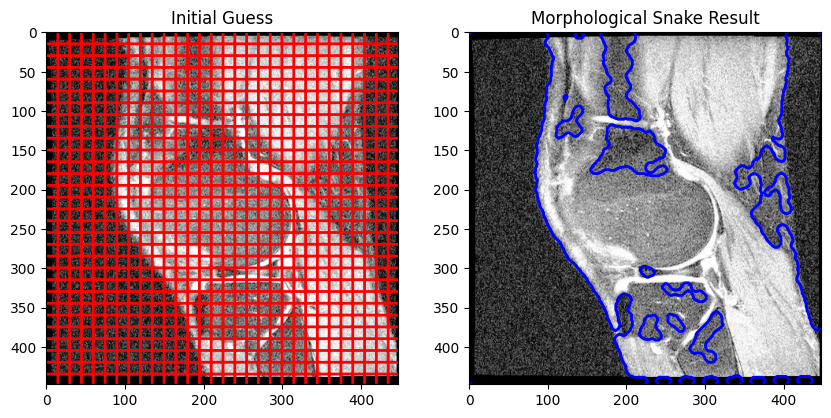

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap="gray")
ax[0].contour(init_mask, [0.5], colors='r', linewidths=2) # Draw initial mask boundary
ax[0].set_title("Initial Guess")

ax[1].imshow(img, cmap="gray")
ax[1].contour(final_mask, [0.5], colors='b', linewidths=2) # Draw final mask boundary
ax[1].set_title("Morphological Snake Result")

plt.show()